In [13]:
%matplotlib inline
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import time as time
import os

colorsBlue = ['#b3e5fc', '#0091ea']
colorsRed = ['#f18e86', '#e83b47']
colorsYellow = ['#fec787', '#fb9d32']
colorsPurple = ['#d69bc5' ,'#a8509f']
colorsGreyOrange = ['#c3c3c3', '#f8a834']
colors = [colorsBlue, colorsRed, colorsYellow, colorsPurple, colorsGreyOrange]
cmap = plt.cm.Blues

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

In [4]:
from utils.dataset import Gen2DDataset
from utils.models import modelFull, modelBottleNeck, modelModular

In [5]:
np.random.seed(219)
torch.manual_seed(219)

In [7]:
Rmask = lambda x, y: (x**2+y**2 < 1) # masking for small radius
funargs = {'sig' : 1/2}
lims = [1, 1]

In [8]:
fracs = 0.5
masks = [lambda x, y: Rmask(x,y) & (np.arctan(np.abs((y - x)/(y + x))) < np.pi / 2 * fracs),
         lambda x, y: Rmask(x,y) & (not (np.arctan(np.abs((y - x)/(y + x))) < np.pi / 2 * fracs))]

set_ID = Gen2DDataset(mask = masks[0], funargs = funargs)
set_OD = Gen2DDataset(mask = masks[1], funargs = funargs)
dataloader_ID = DataLoader(set_ID, batch_size = 64)
dataloader_OD = DataLoader(set_OD, batch_size = 64)

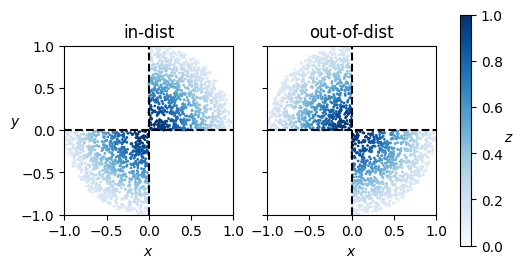

In [9]:
# visualise different mask regions

fig, axes = plt.subplots(1, 2, figsize = (6, 3), sharex = True, sharey = True)

axes[0].set_aspect(1)
xy, z = set_ID.get_all_data()
xy, z = xy.numpy(), z.numpy().flatten()
axes[0].scatter(xy[:, 0], xy[:, 1], c = cmap(z), s = 1)
axes[0].set_title('in-dist')

axes[1].set_aspect(1)
xy, z = set_OD.get_all_data()
xy, z = xy.numpy(), z.numpy().flatten()
axes[1].scatter(xy[:, 0], xy[:, 1], c = cmap(z), s = 1)
axes[1].set_title('out-of-dist')

for i in range(2):
    for j in range(2):
        vv = np.tan(np.pi/4 + (1 - j * 2) * np.pi / 2 * 0.5)
        vv = np.array([1, vv])
        vv = vv / np.sqrt(np.sum(vv ** 2))
        axes[i].plot([-vv[0], vv[0]], [-vv[1], vv[1]],color='black',linestyle = 'dashed', zorder = 100)
    axes[i].set_xlabel('$x$')
    axes[i].set_xlim(-lims[0], lims[0])
    axes[i].set_ylim(-lims[1], lims[1])
axes[0].set_ylabel('$y$', rotation = 0)

cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap), ax = axes, orientation='vertical')
cbar.set_label('$z$', rotation = 0)

# plt.savefig('taskpreview.png', dpi = 300)

In [10]:
models = []
modes = ['modular', 'full', 'bottleneck']
for idx in range(3):
    torch.manual_seed(idx)
    np.random.seed(idx)
    mode = modes[idx]
    if mode == 'modular':
        models.append(modelModular())
    elif mode == 'full':
        models.append(modelFull())
    elif mode == 'bottleneck':
        models.append(modelBottleNeck())
    else:
        raise Exception('unknown mode')

In [11]:
LOSS = []
num_epochs = 2000
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
for idx in range(3):
    model = models[idx]
    model.to(device)
    
    criterion = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr = 1e-3, weight_decay = 0)
    total_params = sum(p.numel() for p in model.parameters())
    print(f'model mode {modes[idx]}, total model parameters is: {total_params}')

    loss_vals = []
    for epoch in range(num_epochs):
        model.train()
        running_loss_ID = 0.0
        for batch_idx, (inputs, targets) in enumerate(dataloader_ID):
            inputs, targets = inputs.to(device), targets.to(device).squeeze(-1)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            running_loss_ID += loss.item()
            loss.backward()
            optimizer.step()
            
        avg_loss_ID = running_loss_ID / len(dataloader_ID)
        
        model.eval()  # Set the model to evaluation mode
        running_loss_OD = 0.0
        with torch.no_grad():  # No gradients needed during validation
            for inputs, targets in dataloader_OD:
                outputs = model(inputs)  # Forward pass
                loss = criterion(outputs, targets.squeeze(-1))  # Compute the validation loss
                running_loss_OD += loss.item()
        avg_loss_OD = running_loss_OD / len(dataloader_OD)
        
        loss_vals.append([avg_loss_ID, avg_loss_OD])
        print(f"Epoch [{epoch+1}/{num_epochs}], ID Loss: {avg_loss_ID:.6f}, OOD Loss : {avg_loss_OD:.6f}", end = '\r')
    print()
    LOSS.append(loss_vals)
LOSS = np.array(LOSS)

model mode modular, total model parameters is: 899
Epoch [2000/2000], ID Loss: 0.000001, OOD Loss : 0.000001
model mode full, total model parameters is: 33537
Epoch [2000/2000], ID Loss: 0.000004, OOD Loss : 0.000808
model mode bottleneck, total model parameters is: 1155
Epoch [2000/2000], ID Loss: 0.000002, OOD Loss : 0.002783


In [14]:
folder = 'results'
if not os.path.exists(folder):
    os.makedirs(folder)
np.save(os.path.join(folder, 'loss_modular_competition.npy'), LOSS)

# save models
for idx in range(3):
    model = models[idx]
    torch.save(model.state_dict(), os.path.join(folder, f'model_{modes[idx]}.pth'))

In [17]:
# load models and loss
LOSS = np.load(os.path.join(folder, 'loss_modular_competition.npy'))
models = []
modes = ['modular', 'full', 'bottleneck']
for idx in range(3):
    model = None
    if modes[idx] == 'modular':
        model = modelModular()
    elif modes[idx] == 'full':
        model = modelFull()
    elif modes[idx] == 'bottleneck':
        model = modelBottleNeck()
    else:
        raise Exception('unknown mode')
    model.load_state_dict(torch.load(os.path.join(folder, f'model_{modes[idx]}.pth'), weights_only=False))
    model.eval()
    models.append(model)

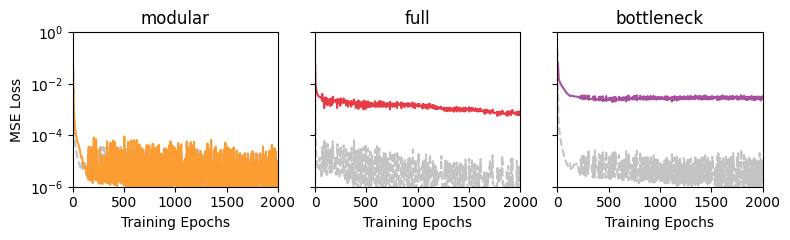

In [ ]:
ccs = [colorsYellow, colorsRed, colorsPurple]
fig, axes = plt.subplots(1, len(modes), figsize = (8, 2.5), sharex = True, sharey = True)
for i in range(len(modes)):
    loss_vals = LOSS[i]
    axes[i].plot(loss_vals[:, 0], color = colors[4][0], linestyle = 'dashed')
    axes[i].plot(loss_vals[:, 1], color = ccs[i][1])
    axes[i].set_title(modes[i])
    axes[i].set_xlabel('Training Epochs')
axes[0].set_yscale('log')
axes[0].set_ylim(1e-6, 1e0)
axes[0].set_xlim(0, 2000)
axes[0].set_ylabel('MSE Loss')
plt.tight_layout()
# plt.savefig('trainingcurves.pdf')

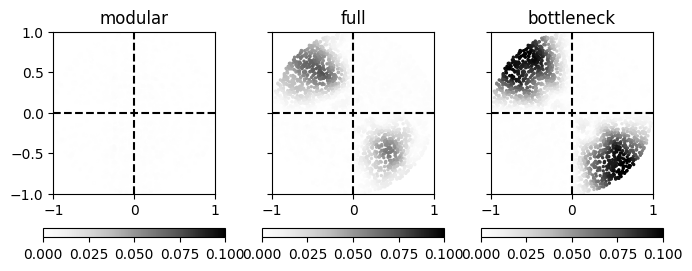

In [22]:
# full dataset
set_FU = Gen2DDataset(mask = Rmask, funargs = funargs)

fig, axes = plt.subplots(1, 3, figsize = (8, 3), sharex = True, sharey = True)

scs = []
for i in range(3):
    xy, z = set_FU.get_all_data()
    model = models[i]
    test_z = model(xy).detach().numpy().flatten()
    xy, z = xy.numpy(), z.numpy().flatten()
    error = np.abs(test_z - z)
    scs.append(axes[i].scatter(xy[:, 0], xy[:, 1], c = error, s = 2, vmin = 0, vmax = 0.1, cmap = 'Greys'))
    axes[i].set_title(modes[i])

    for j in range(2):
        vv = np.tan(np.pi/4 + (1 - j * 2) * np.pi / 2 * 0.5)
        vv = np.array([1, vv])
        vv = vv / np.sqrt(np.sum(vv ** 2))
        axes[i].plot([-vv[0], vv[0]], [-vv[1], vv[1]], color='black',linestyle = 'dashed', zorder = 100)
    axes[i].set_aspect(1)
    
    axes[i].set_xlim(-lims[0], lims[0])
    axes[i].set_ylim(-lims[1], lims[1])
    
for i in range(3):
    fig.colorbar(scs[i], ax=axes[i], orientation='horizontal')

In [23]:
def quadratic(x, a, b):
    return a * x ** 2 + b

Text(0, 0.5, 'y')

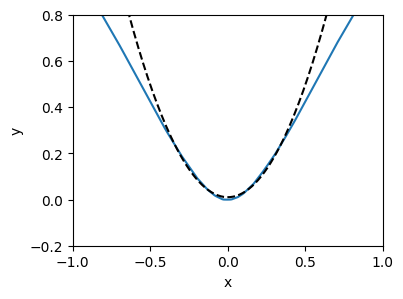

In [28]:
# module = 0
xx = np.linspace(-1, 1, 200)
yy = np.reshape(models[0].mlp_02_x(torch.tensor(xx, dtype = torch.float).unsqueeze(1)).detach().numpy(), -1)
fitting_mask = np.abs(xx) < 0.4
popt, pcov = curve_fit(quadratic, xx[fitting_mask], yy[fitting_mask], p0 = (1, 0))
plt.figure(figsize = (4,3))
plt.plot(xx, yy)
plt.plot(xx, quadratic(xx, *popt), linestyle = 'dashed', color = 'black')
plt.xlim(-1, 1)
plt.ylim(-0.2, 0.8)
plt.xlabel('x')
plt.ylabel('y')
# plt.savefig('mod1.pdf')

Text(0, 0.5, 'y')

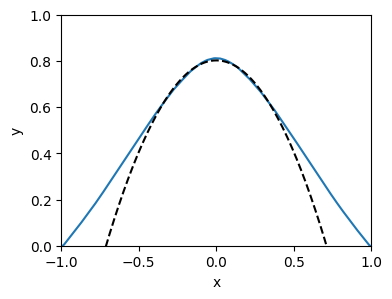

In [29]:
# module = 0
xx = np.linspace(-1, 1, 200)
yy = np.reshape(models[0].mlp_02_y(torch.tensor(xx, dtype = torch.float).unsqueeze(1)).detach().numpy(), -1)
fitting_mask = np.abs(xx) < 0.4
popt, pcov = curve_fit(quadratic, xx[fitting_mask], yy[fitting_mask], p0 = (1, 0))
plt.figure(figsize = (4,3))
plt.plot(xx, yy)
plt.plot(xx, quadratic(xx, *popt), linestyle = 'dashed', color = 'black')
plt.xlim(-1, 1)
plt.ylim(0, 1.0)
plt.xlabel('x')
plt.ylabel('y')
# plt.savefig('mod2.pdf')